# Loading Dataset and Exploring

In [94]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

In [95]:
df = pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

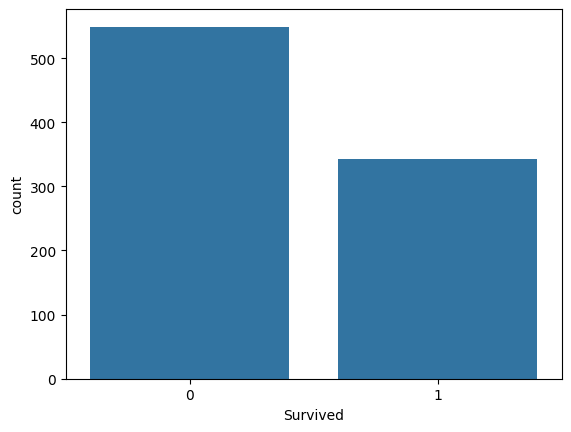

In [96]:
print(df.info())
print(df.isnull().sum())

sns.countplot(x='Survived', data=df)
plt.show()

# Preprocessing

In [97]:
# Drop unnecessary columns
df.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Fill missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical data
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Split features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/tmp/ipykernel_928/2063454549.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_928/2063454549.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

# Train Models

In [98]:
results = []

## 1. Logistic Regression

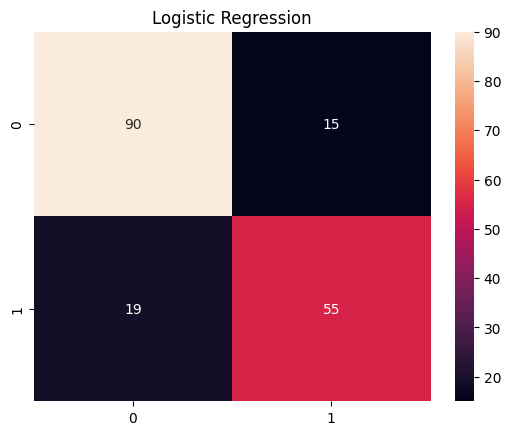

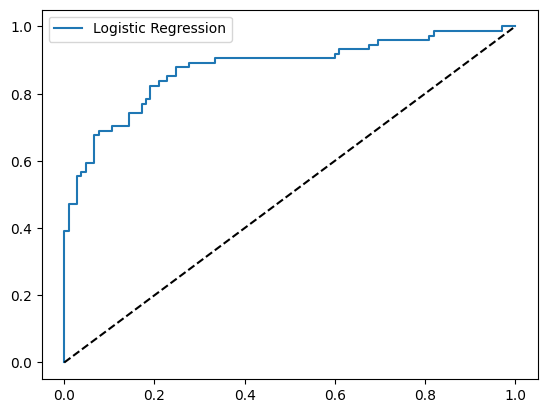

In [99]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
y_prob = model_lr.predict_proba(X_test)[:,1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

results.append(["Logistic Regression", acc, prec, rec, f1, roc])

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

## 2. K-Nearest Neighbors (KNN)

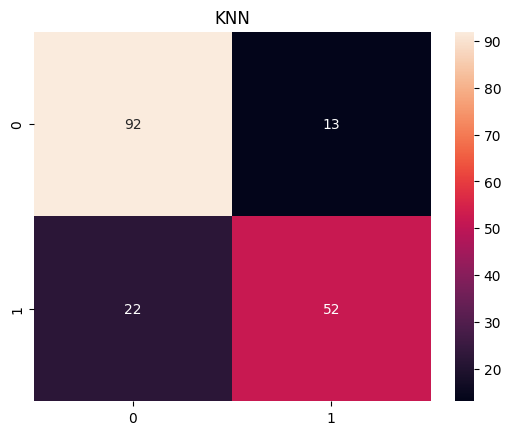

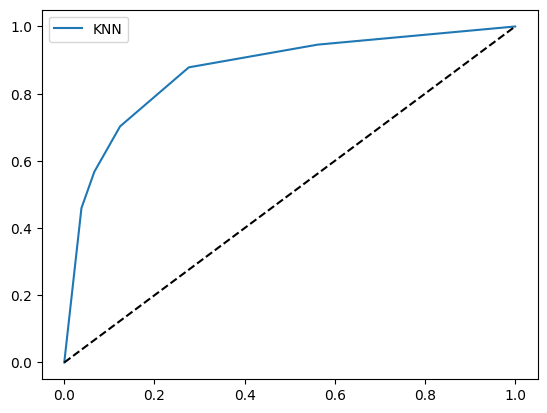

In [100]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

y_pred = model_knn.predict(X_test)
y_prob = model_knn.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

results.append(["KNN", acc, prec, rec, f1, roc])

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("KNN")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="KNN")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

## 3. Decision Tree

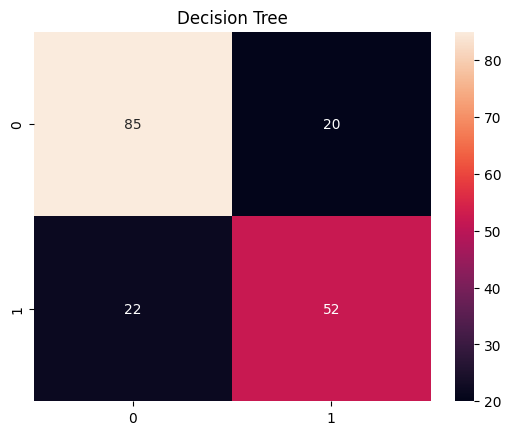

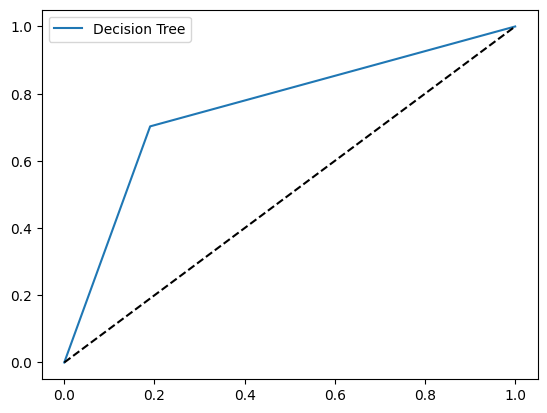

In [101]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

y_pred = model_dt.predict(X_test)
y_prob = model_dt.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

results.append(["Decision Tree", acc, prec, rec, f1, roc])

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

## 4. Random Fores

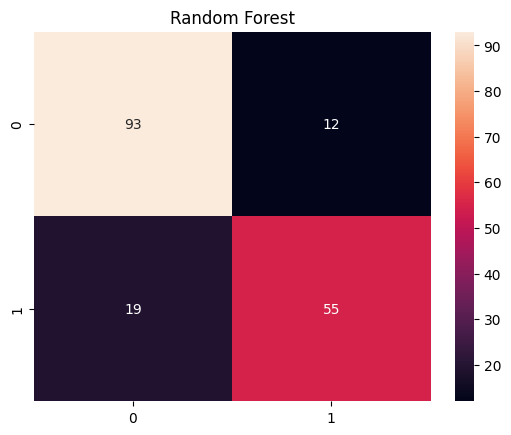

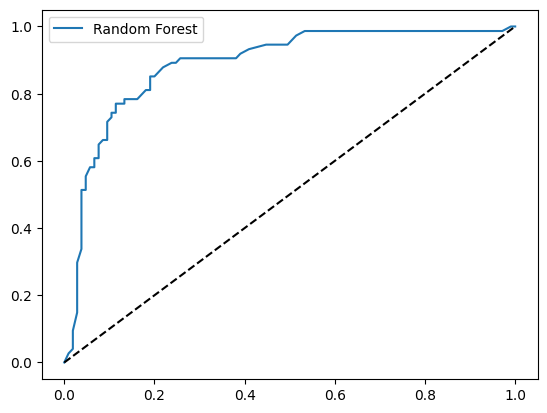

In [102]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
y_prob = model_rf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

results.append(["Random Forest", acc, prec, rec, f1, roc])

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

## 5. Support Vector Machine (SVM)

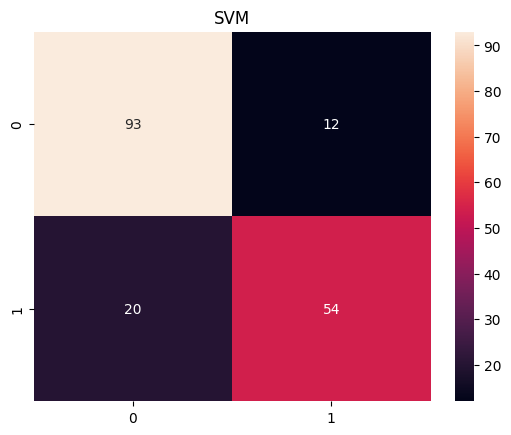

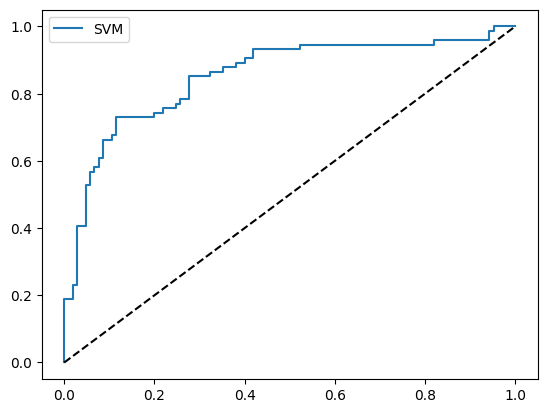

In [103]:
model_svm = SVC(probability=True)
model_svm.fit(X_train, y_train)

y_pred = model_svm.predict(X_test)
y_prob = model_svm.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

results.append(["SVM", acc, prec, rec, f1, roc])

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("SVM")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="SVM")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

## 6. Naïve Bayes

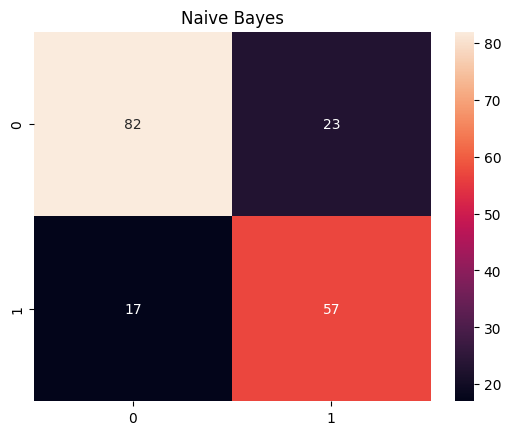

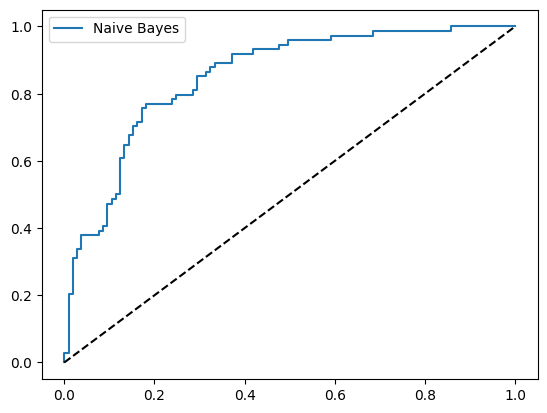

In [104]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred = model_nb.predict(X_test)
y_prob = model_nb.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

results.append(["Naive Bayes", acc, prec, rec, f1, roc])

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Naive Bayes")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="Naive Bayes")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

# Final Comparison (All Models Together)

In [105]:
results_df = pd.DataFrame(results,
                          columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])

print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
3        Random Forest  0.826816   0.820896  0.743243  0.780142  0.888031
4                  SVM  0.821229   0.818182  0.729730  0.771429  0.852252
0  Logistic Regression  0.810056   0.785714  0.743243  0.763889  0.875804
1                  KNN  0.804469   0.800000  0.702703  0.748201  0.867053
5          Naive Bayes  0.776536   0.712500  0.770270  0.740260  0.850837
2        Decision Tree  0.765363   0.722222  0.702703  0.712329  0.756113


ROC comparison

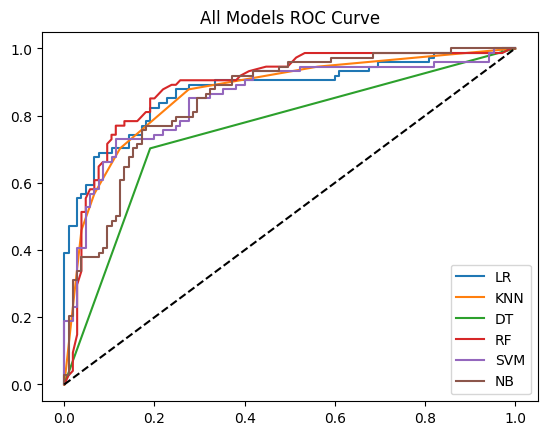

In [106]:
plt.figure()

for name, model in [
    ("LR", model_lr),
    ("KNN", model_knn),
    ("DT", model_dt),
    ("RF", model_rf),
    ("SVM", model_svm),
    ("NB", model_nb)
]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("All Models ROC Curve")
plt.show()

# Conclusion

The performance of multiple classification models was evaluated on the dataset using various metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. Among all the models, Random Forest achieved the best overall performance, demonstrating higher accuracy and better generalization ability.

Logistic Regression and SVM also performed well, providing balanced results across evaluation metrics. However, Decision Tree showed signs of overfitting, while KNN and Naïve Bayes delivered comparatively lower performance.

Thus, Random Forest is concluded to be the most suitable model for this dataset due to its robustness and ability to handle complex data patterns effectively.